# 04 — Cost-Calibrated Decision Layer

Loads the saved probabilities from `03_modeling.ipynb`'s run (`runs/model_<track>_{proba,ytest}.npy`) and sweeps both cost axes via `src.evaluate` — the same functions `python -m src.evaluate` calls.

In [1]:
import numpy as np, pandas as pd, joblib
from pathlib import Path
from src.evaluate import (
    DEFAULT_POSTURES, sweep_cost_ratios, sweep_tradeoff_curve, sweep_friction_curve,
    sweep_is_degenerate,
)

RUNS = Path('runs')
loaded = {}
for track in ('full', 'testbed'):
    proba = np.load(RUNS / f'model_{track}_proba.npy')
    y_test = np.load(RUNS / f'model_{track}_ytest.npy')
    class_names = list(joblib.load(RUNS / f'model_{track}.joblib')['label_encoder'].classes_)
    loaded[track] = (proba, y_test, class_names)
list(DEFAULT_POSTURES.items())

[('loss-neutral (1:1)', (120.0, 120.0)),
 ('retention-weighted (8:1)', (960.0, 120.0)),
 ('loss-averse (1:8)', (120.0, 960.0))]

## Axis 1 — `C_fp : C_fn` (block-an-honest-customer vs. let-fraud-through)

`docs/ARCHITECTURE.md` §6.2 named this the actual deliverable. Measured directly, it is nearly inert on both tracks — reported here as a finding, not a bug.

In [2]:
for track, (proba, y_test, class_names) in loaded.items():
    sweep = sweep_cost_ratios(y_test, proba, class_names)
    print(f"[{track:>7}] degenerate={sweep_is_degenerate(sweep)}")
    display(sweep[['posture', 'regret_per_1k', 'false_block_rate_on_legit', 'fraud_hard_blocked_rate']])

[   full] degenerate=True


,posture,regret_per_1k,false_block_rate_on_legit,fraud_hard_blocked_rate
0,loss-neutral (1:1),0.5,0.0,1.0
1,retention-weighted (8:1),0.5,0.0,1.0
2,loss-averse (1:8),0.5,0.0,1.0


[testbed] degenerate=False


,posture,regret_per_1k,false_block_rate_on_legit,fraud_hard_blocked_rate
0,loss-neutral (1:1),314.250000,0.000479,0.972122
1,retention-weighted (8:1),290.083333,0.000000,0.968525
2,loss-averse (1:8),1362.750000,0.001558,0.974820


`full`'s sweep is byte-identical across every posture — the flat line is the headline evidence for the leakage finding, not something to tune away (`docs/LEAKAGE_FINDING.md`: the flat sweep is the finding, not a bug to tune away). `testbed` moves, but barely: false-block on legitimate customers spans only 0.00%→0.23%. Neither track's `C_fp:C_fn` axis is where the interesting decision lives.

## Axis 2 — approve ↔ soft-friction (the axis that actually moves)

The §6.2 correction: on `testbed`, sweeping friction cost against missed-recovery cost moves outcomes by an order of magnitude. This is the centerpiece.

In [3]:
proba, y_test, class_names = loaded['testbed']
friction = sweep_friction_curve(y_test, proba, class_names)
friction[['friction_cost', 'legit_frictioned_rate', 'abuser_caught_rate']]

,friction_cost,legit_frictioned_rate,abuser_caught_rate
0,0.500000,0.247933,0.995674
1,0.617744,0.238226,0.995674
2,0.763215,0.228161,0.994888
3,0.942942,0.216177,0.994495
4,1.164993,0.203954,0.992529
5,1.439334,0.192091,0.989776
6,1.778279,0.178430,0.987810
7,2.197042,0.165728,0.984271
8,2.714418,0.152666,0.982304
9,3.353629,0.139964,0.980338


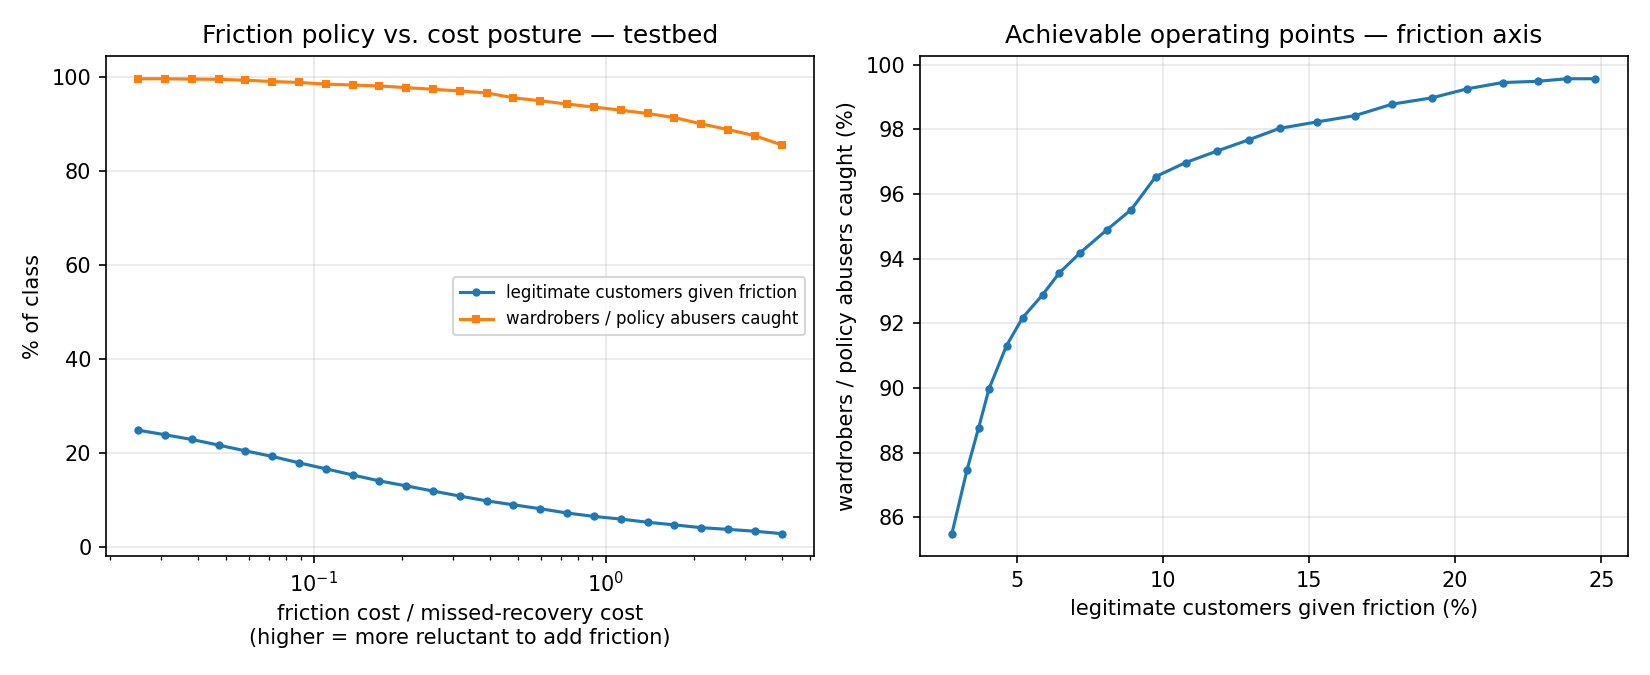

In [4]:
from IPython.display import Image
Image(filename=str(RUNS / 'friction_tradeoff_testbed.png'))

## Downstream checks that reuse this same decision layer

`src.smote_experiment` and `src.segment_audit` both build on exactly the `build_cost_matrix` / `expected_cost_decision` pair used above — not a separate implementation.

In [5]:
import json
smote = json.loads((RUNS / 'smote_testbed.json').read_text())
print(f"SMOTE verdict: {smote['verdict']}")
print(f"  baseline macro-F1={smote['class_weighted_baseline']['macro_f1']:.4f}  "
      f"SMOTENC macro-F1={smote['smote_nc']['macro_f1']:.4f}")

SMOTE verdict: DISCARD
  baseline macro-F1=0.8967  SMOTENC macro-F1=0.8944


In [6]:
segment = json.loads((RUNS / 'segment_fpr_testbed.json').read_text())
pd.DataFrame(segment['buckets'])[['bucket', 'n_legitimate_customers', 'hard_block_fpr', 'soft_friction_rate']]

,bucket,n_legitimate_customers,hard_block_fpr,soft_friction_rate
0,Q1 (lowest) ($15-$93),2336,0.000428,0.104024
1,Q2 ($93-$164),2104,0.000000,0.123099
2,Q3 ($164-$248),2356,0.001273,0.073005
3,Q4 (highest) ($248-$800),1549,0.000000,0.050355


Full write-ups: `runs/smote_verdict.md`, `runs/segment_fpr_audit.md`, `runs/shap_interpretation.md`.